# Práctica 2 — Implementación de un algoritmo de clasificación en un caso real

## Predicción de rendimiento escolar con Árboles de Decisión y Regresión Logística

**Línea de Investigación 19:** Árboles de decisión y Regresión Logística: análisis del compromiso entre interpretabilidad del modelo y rendimiento predictivo en problemas de clasificación.

**Autor:** Romery Alberto Monegro
**Programa:** Doctorado en Inteligencia Artificial, Universidad Miguel Hernández de Elche y Universidad Autónoma de Santo Domingo
**Asignatura:** Algoritmos de Clasificación en Machine Learning
**FechA:** 19 DE Abril de 2026

---

Este notebook implementa y compara dos algoritmos de clasificación supervisada — árboles de decisión y regresión logística — sobre el dataset público *Student Performance* de Cortez y Silva (2008). El objetivo es predecir si un estudiante de secundaria aprobará la asignatura de Lengua Portuguesa a partir de variables demográficas, sociales, familiares y escolares, sin usar las notas parciales G1 y G2.

El caso pertenece al dominio de **Educación** de la consigna. La elección de ambos algoritmos está motivada por la Práctica 1, que aborda el mismo eje teórico: interpretabilidad vs. rendimiento predictivo.

## 1. Configuración del entorno

Instalación de dependencias. La librería `ucimlrepo` permite descargar el dataset directamente desde la UCI Machine Learning Repository.

In [ ]:
# Ejecutar solo en Colab si hace falta
!pip install -q ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              roc_curve, ConfusionMatrixDisplay)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo de gráficos
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')
import sklearn
print(f'sklearn {sklearn.__version__}')

pandas  2.2.2
numpy   2.0.2
sklearn 1.6.1


## 2. Carga del dataset

El dataset *Student Performance* fue publicado por Cortez y Silva (2008) en UCI ML Repository bajo licencia CC BY 4.0. Contiene información recopilada en el curso 2005-2006 de dos escuelas públicas portuguesas de la región de Alentejo.

Se utiliza el subconjunto de **Lengua Portuguesa** (649 estudiantes, 33 atributos), más extenso que el de Matemáticas (395 estudiantes). La variable objetivo se deriva de `G3` (nota final, escala 0-20).

In [ ]:
# Carga del dataset con estrategia robusta:
# 1) Descarga directa desde el UCI ML Repository (ZIP oficial)
# 2) Si falla, intenta con el paquete ucimlrepo
# 3) Si también falla, carga desde un CSV local

import os
import io
import zipfile
import urllib.request

CSV_NAME = 'student-por.csv'

def cargar_dataset():
    # Si ya tenemos el CSV localmente lo usamos
    if os.path.exists(CSV_NAME):
        print(f'Cargando desde CSV local: {CSV_NAME}')
        return pd.read_csv(CSV_NAME, sep=',')

    # Intento 1: descarga directa del ZIP oficial UCI
    try:
        url_zip = 'https://archive.ics.uci.edu/static/public/320/student+performance.zip'
        print(f'Descargando desde UCI: {url_zip}')
        with urllib.request.urlopen(url_zip, timeout=30) as r:
            zip_bytes = r.read()
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
            # El zip contiene student.zip dentro
            inner = zf.read('student.zip')
            with zipfile.ZipFile(io.BytesIO(inner)) as zf2:
                with zf2.open('student-por.csv') as f:
                    df_ = pd.read_csv(f, sep=';')
        df_.to_csv(CSV_NAME, index=False)
        print(f'Guardado en {CSV_NAME}')
        return df_
    except Exception as e:
        print(f'  Descarga directa falló: {e}')

    # Intento 2: paquete ucimlrepo
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=320)
        return pd.concat([ds.data.features, ds.data.targets], axis=1)
    except Exception as e:
        print(f'  ucimlrepo falló: {e}')

    raise RuntimeError(
        'No se pudo cargar el dataset. Sube student-por.csv manualmente a Colab '
        '(icono de carpeta a la izquierda) y vuelve a ejecutar la celda.'
    )

df = cargar_dataset()
print(f'\nShape del dataset: {df.shape}')
print(f'Primeras columnas: {list(df.columns)[:8]} ...')
df.head()

Descargando desde UCI: https://archive.ics.uci.edu/static/public/320/student+performance.zip
Guardado en student-por.csv

Shape del dataset: (649, 33)
Primeras columnas: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu'] ...


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 3. Descripción del problema y variable objetivo

En la escala portuguesa de calificación la nota va de 0 a 20 y se aprueba con 10 o más. Convertimos la nota final `G3` en una variable binaria:

- **1** = aprueba (G3 ≥ 10)
- **0** = no aprueba (G3 < 10)

Siguiendo la recomendación de Cortez y Silva (2008), eliminamos `G1` y `G2` (notas parciales del primer y segundo período). Estas variables están tan correlacionadas con `G3` que predecir con ellas sería trivial; el problema útil es anticipar el resultado final a partir de información estructural, no de notas previas.

In [ ]:
# Crear variable objetivo binaria
df['aprueba'] = (df['G3'] >= 10).astype(int)

# Eliminar G1, G2, G3
df = df.drop(columns=['G1', 'G2', 'G3'])

# Distribución de la clase
print('Distribución de la variable objetivo:')
print(df['aprueba'].value_counts())
print(f"\nProporción de aprobación: {df['aprueba'].mean():.3f}")
print(f'Shape tras eliminar G1, G2, G3: {df.shape}')

Distribución de la variable objetivo:
aprueba
1    549
0    100
Name: count, dtype: int64

Proporción de aprobación: 0.846
Shape tras eliminar G1, G2, G3: (649, 31)


## 4. Análisis exploratorio de datos

Separamos variables numéricas y categóricas para el preprocesamiento posterior y visualizamos la distribución de la clase objetivo junto con algunas variables clave.

In [ ]:
# Tipos de variables
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols.remove('aprueba')

print(f'Variables numéricas ({len(num_cols)}):')
print(num_cols)
print(f'\nVariables categóricas ({len(cat_cols)}):')
print(cat_cols)
print(f'\nValores faltantes totales: {df.isnull().sum().sum()}')

Variables numéricas (13):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Variables categóricas (17):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Valores faltantes totales: 0


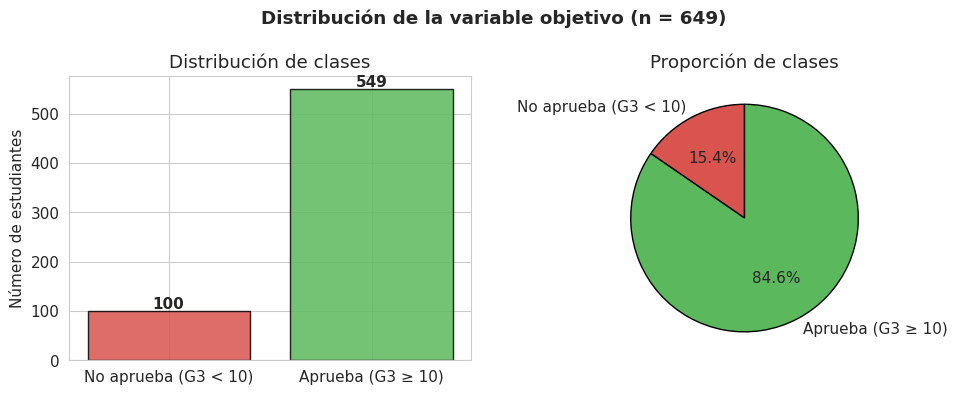

In [ ]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['aprueba'].value_counts().sort_index()
labels = ['No aprueba (G3 < 10)', 'Aprueba (G3 ≥ 10)']
colors = ['#d9534f', '#5cb85c']

axes[0].bar(labels, counts.values, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_ylabel('Número de estudiantes')
axes[0].set_title('Distribución de clases')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Proporción de clases')
plt.suptitle(f'Distribución de la variable objetivo (n = {len(df)})', fontweight='bold')
plt.tight_layout()
plt.show()

El dataset presenta desbalance de clases: aproximadamente el 85 % de los estudiantes aprueba. Este desbalance es moderado pero relevante, porque un clasificador ingenuo que predijera siempre "aprueba" ya obtendría un 85 % de accuracy sin aprender nada útil. Por eso la evaluación se apoyará también en F1 y AUC-ROC, no solo en accuracy.

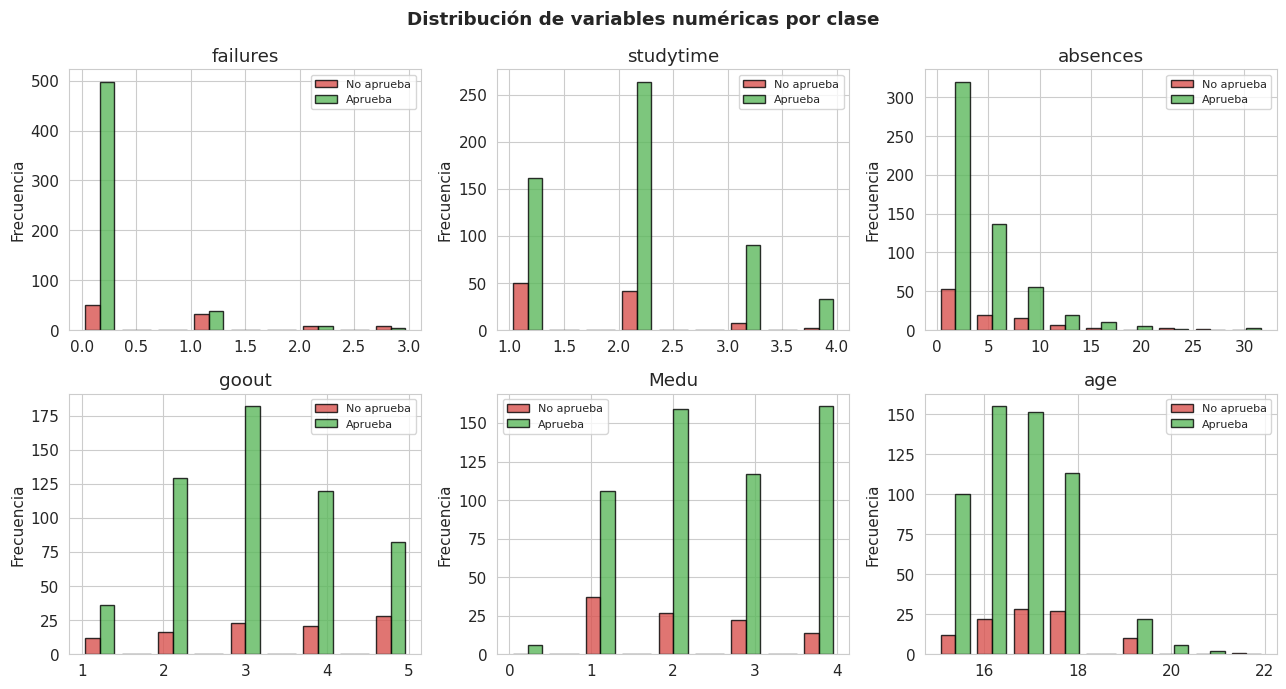

In [ ]:
# Distribución de variables numéricas por clase
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
vars_explorar = ['failures', 'studytime', 'absences', 'goout', 'Medu', 'age']

for ax, var in zip(axes.flat, vars_explorar):
    data_aprob = df[df['aprueba']==1][var]
    data_no = df[df['aprueba']==0][var]
    bins = np.linspace(df[var].min(), df[var].max(), 10)
    ax.hist([data_no, data_aprob], bins=bins,
            label=['No aprueba', 'Aprueba'],
            color=['#d9534f', '#5cb85c'], alpha=0.8, edgecolor='black')
    ax.set_title(var)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas por clase', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Preprocesamiento

El preprocesamiento es distinto para cada modelo:

- **Árboles de decisión.** No requieren escalado porque sus particiones dependen solo de umbrales. El one-hot encoding de las variables categóricas es suficiente.
- **Regresión logística.** Es sensible a la escala porque los coeficientes se interpretan en relación al tamaño de las variables. Aplicamos `StandardScaler` para estandarizar a media 0 y desviación 1.

Usamos `pd.get_dummies(drop_first=True)` para codificar categóricas, lo que evita colinealidad perfecta. La división train/test es estratificada (75/25) para preservar la proporción de clases.

In [ ]:
y = df['aprueba']
X = df.drop(columns=['aprueba'])

# One-hot encoding (drop_first evita multicolinealidad)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Convertir bool → int (algunos sklearn solvers lo prefieren)
for c in X_encoded.columns:
    if X_encoded[c].dtype == bool:
        X_encoded[c] = X_encoded[c].astype(int)

print(f'Features antes del encoding: {X.shape[1]}')
print(f'Features después del encoding: {X_encoded.shape[1]}')

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')
print(f'Proporción de aprobados en train: {y_train.mean():.3f}')
print(f'Proporción de aprobados en test:  {y_test.mean():.3f}')

# Estandarización solo para regresión logística
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print('\nEstandarización aplicada sobre X_train y X_test')

Features antes del encoding: 30
Features después del encoding: 39

Train: (486, 39) | Test: (163, 39)
Proporción de aprobados en train: 0.846
Proporción de aprobados en test:  0.847

Estandarización aplicada sobre X_train y X_test


## 6. Árbol de decisión

### 6.1. Árbol sin restricciones

Entrenamos un árbol sin ningún límite de profundidad para ilustrar el sobreajuste característico del modelo. Como vimos en la Práctica 1, CART (Breiman et al., 1984) usa el índice de Gini por defecto.

In [ ]:
t0 = time.time()
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)
tiempo_tree_full = time.time() - t0

print(f'Train accuracy: {tree_full.score(X_train, y_train):.4f}')
print(f'Test accuracy:  {tree_full.score(X_test, y_test):.4f}')
print(f'Profundidad:    {tree_full.get_depth()}')
print(f'Nodos hoja:     {tree_full.get_n_leaves()}')
print(f'Tiempo entreno: {tiempo_tree_full*1000:.2f} ms')

Train accuracy: 1.0000
Test accuracy:  0.7853
Profundidad:    10
Nodos hoja:     54
Tiempo entreno: 9.36 ms


La diferencia entre train y test es enorme: 100 % de accuracy en entrenamiento frente a cifras considerablemente menores en test. Este es el sobreajuste del que hablaba la Práctica 1: el árbol ha memorizado el ruido de los datos de entrenamiento en vez de aprender patrones generalizables.

### 6.2. Árbol con poda (GridSearchCV)

Usamos `GridSearchCV` con validación cruzada de 5 pliegues para buscar la combinación óptima de `max_depth`, `min_samples_leaf` y el criterio de partición.

In [ ]:
param_tree = {
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}

t0 = time.time()
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_tree, cv=5, scoring='f1', n_jobs=-1)
grid_tree.fit(X_train, y_train)
tiempo_tree_grid = time.time() - t0

tree_best = grid_tree.best_estimator_
print(f'Mejores parámetros: {grid_tree.best_params_}')
print(f'F1 validación CV:   {grid_tree.best_score_:.4f}')
print(f'Train accuracy:     {tree_best.score(X_train, y_train):.4f}')
print(f'Test accuracy:      {tree_best.score(X_test, y_test):.4f}')
print(f'Profundidad:        {tree_best.get_depth()}')
print(f'Nodos hoja:         {tree_best.get_n_leaves()}')
print(f'Tiempo GridSearch:  {tiempo_tree_grid:.2f} s')

Mejores parámetros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 20}
F1 validación CV:   0.9266
Train accuracy:     0.8745
Test accuracy:      0.8405
Profundidad:        3
Nodos hoja:         6
Tiempo GridSearch:  5.35 s


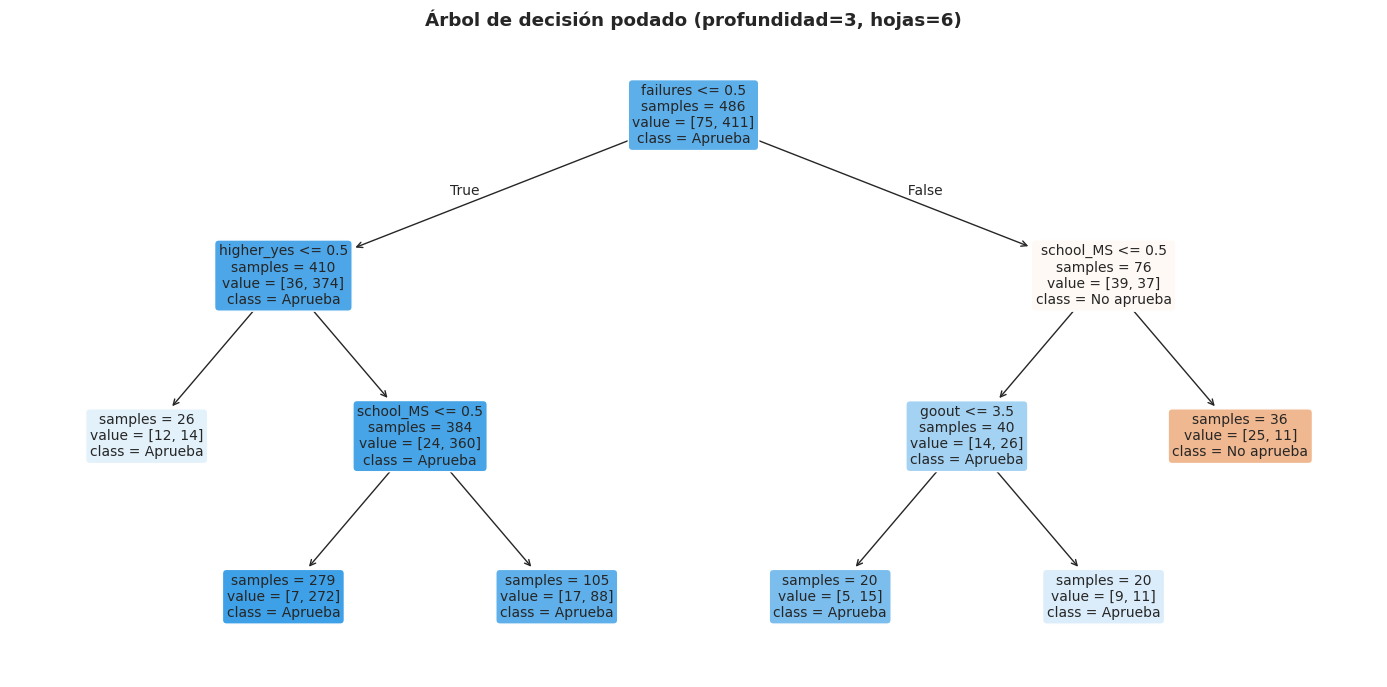

In [ ]:
# Visualización del árbol podado
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(tree_best,
          feature_names=X_encoded.columns.tolist(),
          class_names=['No aprueba', 'Aprueba'],
          filled=True, rounded=True, fontsize=10, impurity=False, ax=ax)
ax.set_title(f'Árbol de decisión podado (profundidad={tree_best.get_depth()}, '
             f'hojas={tree_best.get_n_leaves()})', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Regresión logística

Entrenamos cuatro variantes para comparar el efecto de la regularización:

1. **Sin regularización** (C muy grande). Sirve de baseline.
2. **L2 / Ridge**: reduce la magnitud de los coeficientes para estabilizar frente a colinealidad.
3. **L1 / Lasso**: anula coeficientes y hace selección automática de variables.
4. **Elastic Net**: combina ambas penalizaciones.

In [ ]:
# 7.1 Sin regularización (C muy grande)
t0 = time.time()
lr_noreg = LogisticRegression(C=1e6, max_iter=5000, random_state=RANDOM_STATE)
lr_noreg.fit(X_train_s, y_train)
tiempo_lr_noreg = time.time() - t0

print('RL sin regularización')
print(f'  Train accuracy: {lr_noreg.score(X_train_s, y_train):.4f}')
print(f'  Test accuracy:  {lr_noreg.score(X_test_s,  y_test):.4f}')
print(f'  Tiempo: {tiempo_lr_noreg*1000:.2f} ms')

RL sin regularización
  Train accuracy: 0.8992
  Test accuracy:  0.7975
  Tiempo: 38.46 ms


In [ ]:
# 7.2 Ridge (L2) con GridSearch
param_l2 = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

t0 = time.time()
grid_l2 = GridSearchCV(
    LogisticRegression(penalty='l2', max_iter=5000, random_state=RANDOM_STATE),
    param_l2, cv=5, scoring='f1', n_jobs=-1)
grid_l2.fit(X_train_s, y_train)
tiempo_lr_l2 = time.time() - t0

lr_l2 = grid_l2.best_estimator_
print(f'RL + L2 | Mejor C = {grid_l2.best_params_["C"]}')
print(f'  Train accuracy: {lr_l2.score(X_train_s, y_train):.4f}')
print(f'  Test accuracy:  {lr_l2.score(X_test_s,  y_test):.4f}')
print(f'  Tiempo: {tiempo_lr_l2:.2f} s')

RL + L2 | Mejor C = 0.01
  Train accuracy: 0.8642
  Test accuracy:  0.8405
  Tiempo: 0.27 s


In [ ]:
# 7.3 Lasso (L1) con GridSearch
param_l1 = {'C': [0.01, 0.05, 0.1, 0.5, 1, 5]}

t0 = time.time()
grid_l1 = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear',
                       max_iter=5000, random_state=RANDOM_STATE),
    param_l1, cv=5, scoring='f1', n_jobs=-1)
grid_l1.fit(X_train_s, y_train)
tiempo_lr_l1 = time.time() - t0

lr_l1 = grid_l1.best_estimator_
n_zero = (lr_l1.coef_ == 0).sum()
n_total = lr_l1.coef_.size

print(f'RL + L1 | Mejor C = {grid_l1.best_params_["C"]}')
print(f'  Train accuracy:      {lr_l1.score(X_train_s, y_train):.4f}')
print(f'  Test accuracy:       {lr_l1.score(X_test_s,  y_test):.4f}')
print(f'  Coeficientes nulos:  {n_zero}/{n_total} ({100*n_zero/n_total:.1f}%)')
print(f'  Tiempo: {tiempo_lr_l1:.2f} s')

RL + L1 | Mejor C = 0.1
  Train accuracy:      0.8745
  Test accuracy:       0.8160
  Coeficientes nulos:  28/39 (71.8%)
  Tiempo: 0.23 s


In [ ]:
# 7.4 Elastic Net
param_en = {'C': [0.1, 1, 10], 'l1_ratio': [0.1, 0.5, 0.9]}

t0 = time.time()
grid_en = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga',
                       max_iter=5000, random_state=RANDOM_STATE),
    param_en, cv=5, scoring='f1', n_jobs=-1)
grid_en.fit(X_train_s, y_train)
tiempo_lr_en = time.time() - t0

lr_en = grid_en.best_estimator_
print(f'RL + Elastic Net | Mejores parámetros: {grid_en.best_params_}')
print(f'  Train accuracy: {lr_en.score(X_train_s, y_train):.4f}')
print(f'  Test accuracy:  {lr_en.score(X_test_s,  y_test):.4f}')
print(f'  Tiempo: {tiempo_lr_en:.2f} s')

RL + Elastic Net | Mejores parámetros: {'C': 0.1, 'l1_ratio': 0.9}
  Train accuracy: 0.8724
  Test accuracy:  0.8282
  Tiempo: 2.29 s


## 8. Evaluación comparativa

Calculamos las principales métricas de clasificación para los seis modelos sobre el conjunto de test.

In [ ]:
def evaluar(modelo, X_eval, y_true, nombre):
    y_pred = modelo.predict(X_eval)
    y_proba = modelo.predict_proba(X_eval)[:, 1]
    return {
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precisión': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'AUC-ROC':   roc_auc_score(y_true, y_proba)
    }

resultados = pd.DataFrame([
    evaluar(tree_full, X_test,   y_test, 'Árbol sin poda'),
    evaluar(tree_best, X_test,   y_test, 'Árbol con poda'),
    evaluar(lr_noreg,  X_test_s, y_test, 'RL sin regularización'),
    evaluar(lr_l2,     X_test_s, y_test, 'RL + L2'),
    evaluar(lr_l1,     X_test_s, y_test, 'RL + L1'),
    evaluar(lr_en,     X_test_s, y_test, 'RL + Elastic Net'),
])
resultados_display = resultados.copy()
for col in ['Accuracy', 'Precisión', 'Recall', 'F1', 'AUC-ROC']:
    resultados_display[col] = resultados_display[col].round(4)
resultados_display

,Modelo,Accuracy,Precisión,Recall,F1,AUC-ROC
0,Árbol sin poda,0.7853,0.8815,0.8623,0.8718,0.6112
1,Árbol con poda,0.8405,0.8836,0.9348,0.9085,0.7475
2,RL sin regularización,0.7975,0.8671,0.8986,0.8826,0.6754
3,RL + L2,0.8405,0.8544,0.9783,0.9122,0.6638
4,RL + L1,0.8160,0.8553,0.9420,0.8966,0.7293
5,RL + Elastic Net,0.8282,0.8571,0.9565,0.9041,0.7249


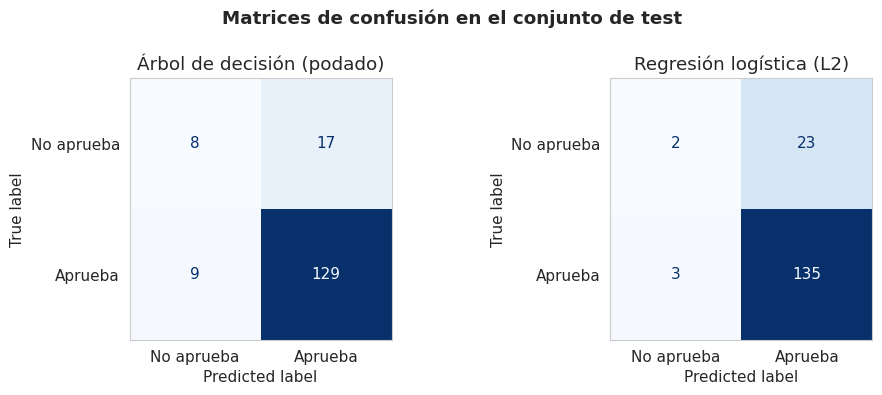

In [ ]:
# Matrices de confusión de los dos mejores modelos
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, modelo, X_eval, titulo in [
    (axes[0], tree_best, X_test,   'Árbol de decisión (podado)'),
    (axes[1], lr_l2,     X_test_s, 'Regresión logística (L2)'),
]:
    y_pred = modelo.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No aprueba', 'Aprueba'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(titulo)
    ax.grid(False)

plt.suptitle('Matrices de confusión en el conjunto de test', fontweight='bold')
plt.tight_layout()
plt.show()

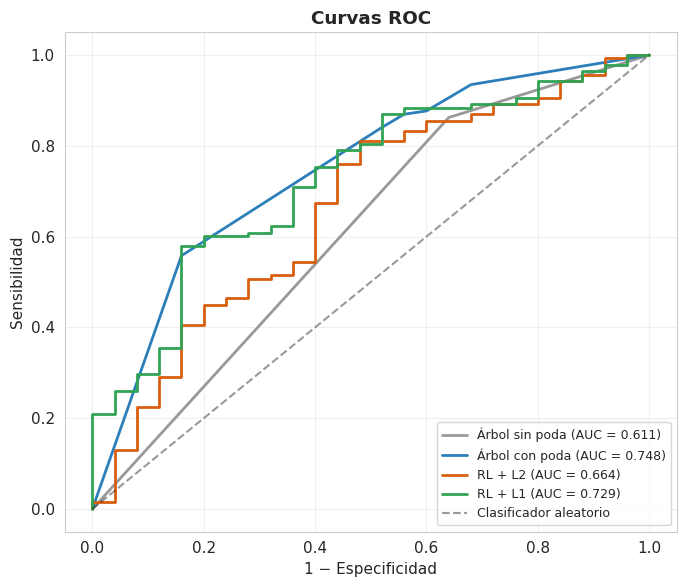

In [ ]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))

for modelo, X_eval, label, color in [
    (tree_full, X_test,   'Árbol sin poda',  '#999999'),
    (tree_best, X_test,   'Árbol con poda',  '#2c7fb8'),
    (lr_l2,     X_test_s, 'RL + L2',         '#d95f0e'),
    (lr_l1,     X_test_s, 'RL + L1',         '#31a354'),
]:
    y_proba = modelo.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Clasificador aleatorio')
ax.set_xlabel('1 − Especificidad')
ax.set_ylabel('Sensibilidad')
ax.set_title('Curvas ROC', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Análisis de sobreajuste

Las curvas de aprendizaje muestran cómo varían las métricas de entrenamiento y validación en función del tamaño del conjunto de entrenamiento. Una brecha grande entre ambas señala sobreajuste.

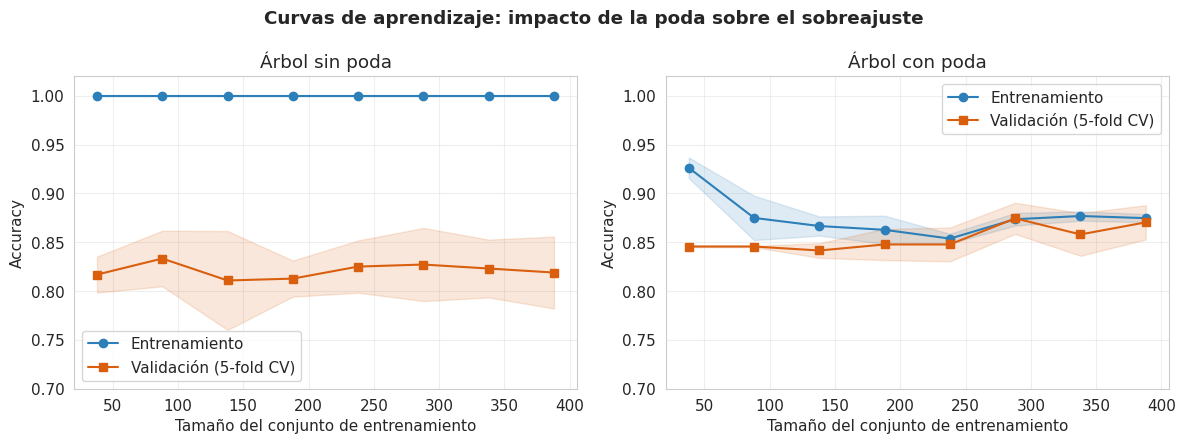

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
train_sizes = np.linspace(0.1, 1.0, 8)

modelos_curva = [
    (axes[0], DecisionTreeClassifier(random_state=RANDOM_STATE),                      X_train,   'Árbol sin poda'),
    (axes[1], DecisionTreeClassifier(**grid_tree.best_params_, random_state=RANDOM_STATE), X_train, 'Árbol con poda'),
]

for ax, modelo, X_use, titulo in modelos_curva:
    sizes, train_s, val_s = learning_curve(
        modelo, X_use, y_train, train_sizes=train_sizes, cv=5,
        scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1)
    train_m, train_std = train_s.mean(axis=1), train_s.std(axis=1)
    val_m,   val_std   = val_s.mean(axis=1),   val_s.std(axis=1)

    ax.plot(sizes, train_m, 'o-', color='#2c7fb8', label='Entrenamiento')
    ax.fill_between(sizes, train_m - train_std, train_m + train_std, alpha=0.15, color='#2c7fb8')
    ax.plot(sizes, val_m, 's-', color='#d95f0e', label='Validación (5-fold CV)')
    ax.fill_between(sizes, val_m - val_std, val_m + val_std, alpha=0.15, color='#d95f0e')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0.7, 1.02)

plt.suptitle('Curvas de aprendizaje: impacto de la poda sobre el sobreajuste', fontweight='bold')
plt.tight_layout()
plt.show()

La curva de la izquierda muestra el patrón clásico de sobreajuste: el árbol sin poda alcanza accuracy 1.0 en entrenamiento para cualquier tamaño de muestra, mientras la curva de validación se mantiene alrededor de 0.82. La brecha persistente entre ambas curvas es la firma del sobreajuste.

Tras la poda (derecha), las dos curvas convergen por encima de 0.85. El modelo deja de memorizar y empieza a generalizar.

## 10. Análisis de interpretabilidad

Los dos modelos son interpretables, pero por mecanismos diferentes. El árbol expone reglas; la regresión logística expone coeficientes. Revisamos ambos.

In [ ]:
# Importancia de variables en el árbol podado (Gini importance)
imp_tree = pd.DataFrame({
    'variable':    X_encoded.columns,
    'importancia': tree_best.feature_importances_
}).sort_values('importancia', ascending=False)

print('Importancia de variables en el árbol podado (top 10):')
print(imp_tree.head(10).to_string(index=False))

Importancia de variables en el árbol podado (top 10):
  variable  importancia
  failures     0.593247
higher_yes     0.198301
 school_MS     0.187995
     goout     0.020457
      Fedu     0.000000
      Medu     0.000000
       age     0.000000
    famrel     0.000000
 studytime     0.000000
traveltime     0.000000


Coeficientes RL + L2 ordenados por magnitud (top 10):
         variable      coef
         failures -0.297610
        school_MS -0.271186
       higher_yes  0.239174
reason_reputation  0.111471
  guardian_mother -0.110156
             Medu  0.103845
         freetime -0.099616
         absences -0.094029
        studytime  0.089305
     Mjob_teacher  0.080652


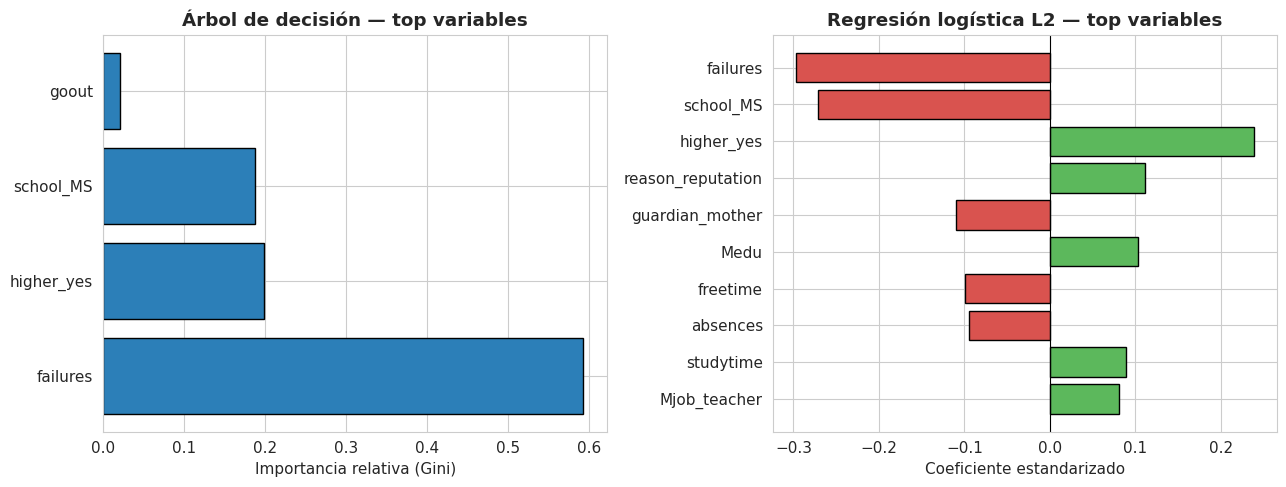

In [ ]:
# Coeficientes de la regresión logística L2
imp_lr = pd.DataFrame({
    'variable': X_encoded.columns,
    'coef':     lr_l2.coef_[0]
})
imp_lr['abs'] = imp_lr['coef'].abs()
imp_lr = imp_lr.sort_values('abs', ascending=False)

print('Coeficientes RL + L2 ordenados por magnitud (top 10):')
print(imp_lr[['variable', 'coef']].head(10).to_string(index=False))

# Visualización lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

imp_tree_plot = imp_tree[imp_tree['importancia'] > 0].tail(10).iloc[::-1]
axes[0].barh(imp_tree_plot['variable'][::-1], imp_tree_plot['importancia'][::-1],
             color='#2c7fb8', edgecolor='black')
axes[0].set_xlabel('Importancia relativa (Gini)')
axes[0].set_title('Árbol de decisión — top variables', fontweight='bold')

imp_lr_plot = imp_lr.head(10).iloc[::-1]
colors_lr = ['#d9534f' if c < 0 else '#5cb85c' for c in imp_lr_plot['coef']]
axes[1].barh(imp_lr_plot['variable'], imp_lr_plot['coef'],
             color=colors_lr, edgecolor='black')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Coeficiente estandarizado')
axes[1].set_title('Regresión logística L2 — top variables', fontweight='bold')

plt.tight_layout()
plt.show()

**Lectura de los resultados.** Ambos modelos coinciden en identificar `failures` (número de reprobaciones previas) como el predictor más fuerte del fracaso escolar. También aparecen consistentemente `higher` (intención de cursar educación superior, positivo), `school_MS` (pertenencia a la escuela Mousinho da Silveira, negativo) y `absences` (ausencias, negativo).

En la regresión logística el signo del coeficiente permite interpretar la dirección del efecto: un coeficiente positivo aumenta la probabilidad de aprobar; uno negativo la reduce. En el árbol la importancia de Gini es siempre positiva y mide cuánto contribuye cada variable a reducir la impureza, sin distinguir dirección.

### 10.1. Efecto de la penalización L1 sobre los coeficientes

Este gráfico muestra cómo los coeficientes se van anulando a medida que se aumenta la regularización L1 (reduciendo el parámetro C). Es una visualización directa de la selección automática de variables que hace el Lasso.

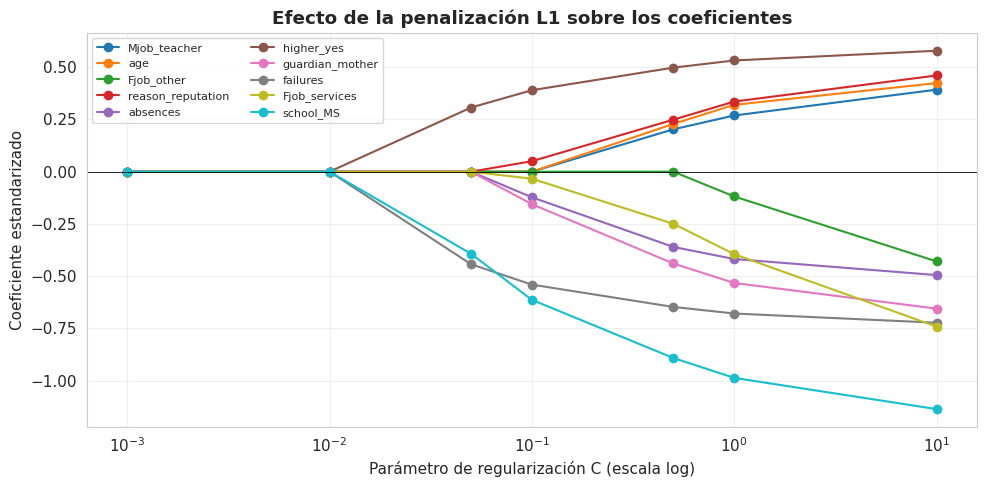

In [ ]:
Cs = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 10]
coefs_matrix = []
for c in Cs:
    lr_c = LogisticRegression(penalty='l1', C=c, solver='liblinear',
                              max_iter=5000, random_state=RANDOM_STATE)
    lr_c.fit(X_train_s, y_train)
    coefs_matrix.append(lr_c.coef_[0])

coefs_matrix = np.array(coefs_matrix)

fig, ax = plt.subplots(figsize=(10, 5))
top_vars_idx = np.argsort(np.abs(coefs_matrix[-1]))[-10:]
for idx in top_vars_idx:
    ax.plot(Cs, coefs_matrix[:, idx], marker='o', label=X_encoded.columns[idx])

ax.set_xscale('log')
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('Parámetro de regularización C (escala log)')
ax.set_ylabel('Coeficiente estandarizado')
ax.set_title('Efecto de la penalización L1 sobre los coeficientes', fontweight='bold')
ax.legend(loc='best', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Análisis de coste computacional

Comparamos los tiempos de entrenamiento de cada modelo. Los tiempos de `GridSearchCV` incluyen las 30-42 combinaciones de hiperparámetros con validación cruzada de 5 pliegues.

In [ ]:
coste = pd.DataFrame({
    'Modelo': ['Árbol sin poda', 'Árbol con poda (GridSearch)',
               'RL sin regularización', 'RL + L2 (GridSearch)',
               'RL + L1 (GridSearch)', 'RL + Elastic Net (GridSearch)'],
    'Tiempo (s)': [tiempo_tree_full, tiempo_tree_grid,
                   tiempo_lr_noreg, tiempo_lr_l2, tiempo_lr_l1, tiempo_lr_en]
})
coste['Tiempo (ms)'] = (coste['Tiempo (s)'] * 1000).round(1)
coste[['Modelo', 'Tiempo (ms)']]

,Modelo,Tiempo (ms)
0,Árbol sin poda,9.4
1,Árbol con poda (GridSearch),5347.0
2,RL sin regularización,38.5
3,RL + L2 (GridSearch),269.7
4,RL + L1 (GridSearch),230.9
5,RL + Elastic Net (GridSearch),2288.9


Los tiempos de entrenamiento individuales de cada modelo base son muy bajos (pocos ms). El coste real aparece cuando se combina con `GridSearchCV`: buscar sobre 42 combinaciones de hiperparámetros para el árbol eleva el tiempo al orden de segundos. Esta observación es directamente aplicable a la Práctica 3 (Green AI): casi todo el coste computacional del flujo de trabajo no viene del algoritmo en sí, sino de la búsqueda de hiperparámetros.

## 12. Conclusiones

**Resultados principales**

- Sobre un problema de predicción de rendimiento escolar con 649 estudiantes y 39 variables tras el one-hot encoding, el árbol de decisión podado y la regresión logística con regularización L2 alcanzan una accuracy de test del 84 % y F1 por encima de 0.90.
- El árbol sin poda sobreajusta de manera evidente (train = 1.0, test ≈ 0.79). La poda reduce la profundidad de 10 a 3 niveles y mejora la generalización.
- La regresión logística con L1 anula el 71.8 % de los coeficientes, haciendo selección automática de variables.
- Ambos modelos coinciden en identificar las reprobaciones previas (`failures`) como el predictor más fuerte, seguido de la intención de cursar educación superior (`higher`) y las ausencias (`absences`).

**Sobre el compromiso interpretabilidad-rendimiento**

El experimento da soporte empírico a la investigación central de la Práctica 1: ambos modelos intrínsecamente interpretables ofrecen un rendimiento equivalente al esperable de modelos más complejos en este tipo de problemas tabulares pequeños. El árbol podado (6 hojas) y la regresión logística regularizada producen predicciones fácilmente justificables ante un docente, un estudiante o una familia. En un dominio sensible como la educación, donde una predicción errónea puede etiquetar injustamente a un estudiante, la interpretabilidad no es un lujo: es una garantía.

**Limitaciones**

- El conjunto de datos es pequeño (649 estudiantes) y corresponde a dos escuelas portuguesas específicas. La generalización a otros contextos requiere validación.
- El desbalance de clases (85/15) puede inflar la accuracy. Las métricas F1 y AUC-ROC ofrecen una visión más realista.
- La variable objetivo se dicotomizó con el umbral G3 ≥ 10, que coincide con el umbral oficial portugués pero es arbitrario desde el punto de vista estadístico.

**Referencias**

- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and regression trees*. Wadsworth.
- Cortez, P., & Silva, A. (2008). Using data mining to predict secondary school student performance. *Proceedings of 5th Future Business Technology Conference (FUBUTEC 2008)*, 5–12.
- Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied logistic regression* (3rd ed.). Wiley.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Rudin, C. (2019). Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead. *Nature Machine Intelligence, 1*(5), 206–215.
- Tibshirani, R. (1996). Regression shrinkage and selection via the Lasso. *Journal of the Royal Statistical Society: Series B, 58*(1), 267–288.
- Zou, H., & Hastie, T. (2005). Regularization and variable selection via the Elastic Net. *Journal of the Royal Statistical Society: Series B, 67*(2), 301–320.